[[0.61033773 0.86329729]
 [0.91271028 0.37652378]
 [0.90635532 0.96630768]
 [0.99434266 0.1087176 ]
 [0.65331178 0.35604718]
 [0.64256515 0.60365483]
 [0.0750256  0.50478539]
 [0.05863407 0.15781983]
 [0.43136146 0.35648432]
 [0.4293647  0.37249507]
 [0.70259311 0.00311265]
 [0.74271011 0.52058625]
 [0.05738328 0.23165392]
 [0.98929803 0.51021959]
 [0.51773501 0.77511011]
 [0.69721972 0.76610849]
 [0.97295092 0.20172918]
 [0.55788682 0.17848046]
 [0.36904817 0.83716464]
 [0.57005835 0.47789691]
 [0.52777601 0.97339412]
 [0.6301106  0.64505491]
 [0.59448059 0.56516823]
 [0.14395118 0.81983795]
 [0.60127776 0.55882208]
 [0.88379912 0.09116625]
 [0.15116173 0.8220891 ]
 [0.28968223 0.2772613 ]
 [0.94533808 0.84767877]
 [0.00847795 0.45799686]
 [0.43863642 0.43136536]
 [0.23380876 0.15857743]
 [0.77690894 0.78117143]
 [0.94354823 0.47421342]
 [0.34374576 0.96172121]
 [0.76128629 0.96321665]
 [0.89675765 0.90324457]
 [0.25107606 0.33995254]
 [0.63699527 0.82158631]
 [0.55457596 0.72898247]


KeyboardInterrupt: 

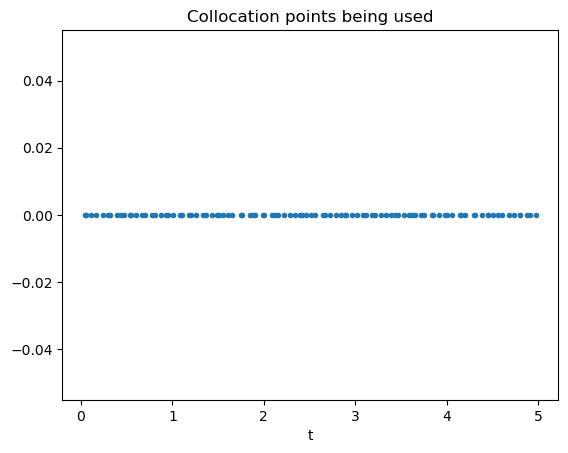

In [3]:
#!/usr/bin/env python
# coding: utf-8

# In[168]:


import tensorflow as tf
import numpy as np
from pyDOE import lhs
import matplotlib.pyplot as plt

# import pydot
# import graphviz
# import math
# from matplotlib import cm
# from matplotlib.ticker import LinearLocator

import time
import random


# In[169]:


tf.keras.backend.set_floatx('float64')


# In[170]:


a = 2/3
b = 4/3
c = 1
d = 1


# In[171]:


def rklv(u, t_start, t_end, t_step_size) :
    
    [x0, y0] = u

    def rk4(r, t, h):                    #edited; no need for input f
            """ Runge-Kutta 4 method """
            k1 = h*f(r, t)
            k2 = h*f(r+0.5*k1, t+0.5*h)
            k3 = h*f(r+0.5*k2, t+0.5*h)
            k4 = h*f(r+k3, t+h)
            return (k1 + 2*k2 + 2*k3 + k4)/6

    def f(r, t):
            x, y = r[0], r[1]
            fxd = a*x - b*x*y
            fyd = c*x*y - d*y
            return np.array([fxd, fyd], float)

    h=t_step_size                               #edited
    tpoints = np.arange(t_start, t_end + h, h)         #edited
    xpoints, ypoints  = [], []
    r = np.array([x0, y0], float)
    for t in tpoints:
            xpoints.append(r[0])          #edited
            ypoints.append(r[1])          #edited
            r += rk4(r, t, h)             #edited; no need for input f
            
#     plt.plot(xpoints, ypoints)
#     plt.xlabel("x")
#     plt.ylabel("y")
#     plt.show()

    tarr = np.asarray(tpoints)
    xarr = np.asarray(xpoints)
    yarr = np.asarray(ypoints)

    points = np.vstack((tarr, xarr, yarr))

    return points


# In[172]:


rklv([0.9, 0.9], 0, 12, 0.01)


# In[173]:


def define_collocation_points(t_bdry, N_points=100):

    colloc_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N_points)

    return colloc_points


# In[174]:


M = 2
N = 100
P = 100


t0 = 0.0
tfinal = 5.0
t_step = 0.01


class Normalize(tf.keras.layers.Layer):
  def __init__(self, xmin, xmax, name=None, **kwargs):
    super(Normalize, self).__init__(name=name)
    self.xmin = xmin
    self.xmax = xmax
    super(Normalize, self).__init__(**kwargs)

  def call(self, inputs):
    return 2.0*(inputs-self.xmin)/(self.xmax-self.xmin)-1.0

  def get_config(self):
    config = super(Normalize, self).get_config()
    config.update({'xmin': self.xmin, 'xmax': self.xmax})
    return config


# In[175]:

def build_model(num_layers = 4, num_units = 60, summary = False) :
    
    inp_br_init = br = tf.keras.layers.Input(shape = (2,), name = "Input_br_init")
    
    for i in range(num_layers) :
        
        br = tf.keras.layers.Dense(num_units, activation = 'tanh', name = "Hidden_br_" + str(i))(br)
        
    out_br_x = tf.keras.layers.Dense(1, activation = 'linear', name = "output_br_x")(br)
    out_br_y = tf.keras.layers.Dense(1, activation = 'linear', name = "output_br_y")(br)
    
    
    inp_tr = tr = tf.keras.layers.Input(shape = (1,), name = "Input_tr")
    
    tr = Normalize(t0, tfinal)(tr)
    
    for i in range(num_layers) :
        
        tr = tf.keras.layers.Dense(num_units, activation = 'tanh', name = "Hidden_tr_" + str(i))(tr)
        
    out_tr_x = tf.keras.layers.Dense(1, activation = 'linear', name = "output_tr_x")(tr)
    out_tr_y = tf.keras.layers.Dense(1, activation = 'linear', name = "output_tr_y")(tr)

    mult_x = tf.keras.layers.Multiply(name = "multiply_x")([out_br_x, out_tr_x])
    mult_y = tf.keras.layers.Multiply(name = "multiply_y")([out_br_y, out_tr_y])
    
    out_x = tf.keras.layers.Dense(1, name = "output_x")(mult_x)
    out_y = tf.keras.layers.Dense(1, name = "output_y")(mult_y)
    
    model = tf.keras.models.Model([inp_br_init, inp_tr], [out_x, out_y])
    
    if summary :
        
        model.summary()
        
    return model


# In[177]:


u_data = np.random.rand(N, M)
print(u_data)
first_u_data = u_data[0, :]
last_u_data = u_data[-1, :]

# In[178]:


def clone_u_data (data) :
    
    new_data = np.zeros((N*P, M))
    
    for i in range(N) :
        
        data_row = data[i]
        
        cloned_data = np.tile(data_row, (P,1))
        
        new_data[i*P:(i + 1)*P, :] = cloned_data
        
    return new_data


# In[179]:


def clone_t_data (data) :
    
    new_data = np.tile(data, (N,1))
    
    return new_data


# In[180]:


u_data = clone_u_data(u_data)
u_train = u_data


# In[181]:


colloc = define_collocation_points([t0, tfinal], P)
plt.plot(colloc[:,0], 0 * colloc[:,0],'.')
plt.xlabel('t')
plt.title('Collocation points being used')


# In[182]:


t_init = np.zeros((N*P, 1))


# In[183]:


decimal_p = int((np.floor(np.log10(1/t_step))))
# print(decimal_p)


# In[184]:


t_data = colloc
t_data = clone_t_data(t_data)

t_data = np.around(t_data, decimal_p)
t_train = t_data


# In[185]:


true_data = np.zeros((N*P, 2))

# for i in range(N*P) :
    
    # u = u_train[i]
    # t = t_train[i]
    
    # sol_points = rklv(u, t0, tfinal, t_step)
    
    # t_sol = sol_points[0]
    # t_sol = np.around(t_sol, decimal_p)
    
    # x_sol = sol_points[1]
    # y_sol = sol_points[2]
    
    # index = np.where(t_sol == t)
    
    # true_data[i][0] = x_sol[index][0]
    # true_data[i][1] = y_sol[index][0]
    
# print(true_data.shape)


# In[186]:


u_train[:, :2] = np.log(u_train[:, :2])

u_t_train = np.column_stack((u_train, t_train))

np.random.shuffle(u_t_train)

u_train = u_t_train[:, :2]
t_train = u_t_train[:, 2:]

print(u_train)
print(t_train)

# true_data = np.log(true_data)


# In[187]:


# The main training function
@tf.function
def train_network(model, u_cond, t, x_true, y_true, x_init, y_init, V, alpha, beta, gamma, delta):

    with tf.GradientTape() as tape1:

        with tf.GradientTape(persistent=True) as tape2:
            
            tape2.watch(t)
            [x, y] = model([u_cond, t], training=True)
            
            x = x_init + tf.keras.activations.relu(t)*x
            y = y_init + tf.keras.activations.relu(t)*y
          
        
        xt = tape2.gradient(x, t)
        yt = tape2.gradient(y, t)
        
        xt = tf.reshape(xt, [N*P, 1])
        yt = tf.reshape(yt, [N*P, 1])
 
        Gloss = tf.reduce_mean(tf.square(x - x_true) + tf.square(y - y_true))
        
        eqn1 = xt - a + b*(tf.math.exp(y))
        eqn2 = yt - c*(tf.math.exp(x)) + d
        
        DEloss = tf.reduce_mean(tf.square(eqn1) + tf.square(eqn2))
                         
        [x_init_pred, y_init_pred] = model([u_cond, t_init], training=True)
        
        x_init_pred = x_init + t_init*x_init_pred
        y_init_pred = y_init + t_init*y_init_pred
        
        # IVloss = tf.reduce_mean(tf.square(x_init_pred - x_init) + tf.square(y_init_pred - y_init))
    
        v = (c * (tf.math.exp(x))) - (d * x) + (b * tf.math.exp(y)) - (a * y)
    
        Vloss = tf.reduce_mean(tf.square(v - V))
        
        # loss = alpha*Gloss + beta*DEloss + gamma*IVloss + delta*Vloss
        
        loss = beta*DEloss + delta*Vloss

    grads = tape1.gradient(loss, model.trainable_variables)
    
    # return Gloss, DEloss, IVloss, Vloss, grads
    return DEloss, Vloss, grads


# In[188]:


def DeepONet_train(model, u, t, G_true, epochs, alpha_val, beta_val, gamma_val, delta_val):

    lr_model = 1e-3
    
    alpha = alpha_val
    beta = beta_val
    gamma = gamma_val
    delta = delta_val
    
    u_cond = u
    
    x_init = u[:, 0].reshape(-1, 1)
    y_init = u[:, 1].reshape(-1, 1)
    
    
    V = (c * (np.exp(x_init))) - (d * x_init) + (b * np.exp(y_init)) - (a * y_init)
      
    x_true = G_true[:, 0].reshape(-1, 1)
    y_true = G_true[:, 1].reshape(-1, 1)
    
    print(u_cond.shape, x_init.shape, y_init.shape, V.shape, x_true.shape, y_true.shape)

    epoch_loss = np.zeros(epochs)
    
    opt = tf.keras.optimizers.Adam(lr_model)

    for i in range(epochs):

        # Gloss, DEloss, IVloss, Vloss, grads = train_network(model, u_cond, t, x_true, y_true, x_init, y_init, V,
                                                     # alpha, beta, gamma, delta)
                                                     
        DEloss, Vloss, grads = train_network(model, u_cond, t, x_true, y_true, x_init, y_init, V,
                                                     alpha, beta, gamma, delta)
                                                     
        opt.apply_gradients(zip(grads, model.trainable_variables))
      
        # epoch_loss[i] += alpha*Gloss + beta*DEloss + gamma*IVloss + delta*Vloss
        epoch_loss[i] += beta*DEloss + delta*Vloss
    
        if (np.mod(i, 100)==0):
       
            # print("Gloss, DE loss, IV loss, Vloss in {}th epoch: {: 6.4f}, {: 6.4f}, {: 6.4f}, {: 6.4f}.".format(
                # i, Gloss, DEloss, IVloss, Vloss))
                
            print("DE loss, Vloss in {}th epoch: {: 6.4f}, {: 6.4f}.".format(
                i, DEloss, Vloss))
                
    return epoch_loss, model


# In[189]:


alpha = 1
beta = 10
gamma = 1
delta = 1

epochs = 50000


# In[190]:


model = build_model(summary = True)
tf.keras.utils.plot_model(model, to_file = 'DeepLV-NoParams-NoIV-SeparateInputes.png')

loss, model = DeepONet_train(model, u_train, t_train, true_data, epochs, alpha, beta, gamma, delta)


# In[ ]:


test_u = first_u_data
test_t = np.arange(0, tfinal + t_step, t_step).reshape(-1, 1)

sol = rklv(test_u, t0, tfinal, t_step)
x_sol = sol[1].reshape(-1, 1)
y_sol = sol[2].reshape(-1, 1)

test_u = np.tile(test_u, (len(test_t),1))
test_u_cond = np.log(test_u)


# In[ ]:


[test_x, test_y] = model([test_u_cond, test_t], training=True)

test_x = test_u_cond[:, 0].reshape(-1, 1) + test_t*test_x
test_y = test_u_cond[:, 1].reshape(-1, 1) + test_t*test_y

test_x = np.exp(test_x)
test_y = np.exp(test_y)


mse = ((test_x - x_sol)**2 + (test_y - y_sol)**2).mean(axis = 0 )
print("mse_first", mse)




# In[ ]:


test_u = last_u_data
test_t = np.arange(0, tfinal + t_step, t_step).reshape(-1, 1)

sol = rklv(test_u, t0, tfinal, t_step)
x_sol = sol[1].reshape(-1, 1)
y_sol = sol[2].reshape(-1, 1)

test_u = np.tile(test_u, (len(test_t),1))
test_u_cond = np.log(test_u)


# In[ ]:


[test_x, test_y] = model([test_u_cond, test_t], training=True)

test_x = test_u_cond[:, 0].reshape(-1, 1) + test_t*test_x
test_y = test_u_cond[:, 1].reshape(-1, 1) + test_t*test_y

test_x = np.exp(test_x)
test_y = np.exp(test_y)


mse = ((test_x - x_sol)**2 + (test_y - y_sol)**2).mean(axis = 0 )
print("mse_last", mse)